# CoT Commitment Point Experiment
### Qwen2.5-14B-Instruct | GSM8K | Activation Patching | 4 Semantic Stages

**What this notebook does:**
1. Loads Qwen2.5-14B in NF4 on a single T4 (~10 GB)
2. Collects paired traces from GSM8K: correct (greedy) + wrong (temperature-sampled)
3. For each pair × 4 stages, patches correct-trace activations into wrong-trace forward pass
4. Plots a flip-rate curve — the commitment point signature

**Stages:** `setup → computation → transition → conclusion`  
**Flip rate** = fraction of incorrect traces steered to the correct answer by patching that stage

---
> Set `PILOT_MODE = True` for a ~30 min test on 10 pairs.  
> Set `PILOT_MODE = False` for the full 80-pair run (~3.5 hrs).

## 0 · Install dependencies

In [1]:
# Run once per Kaggle session. Restart kernel after this cell.
!pip install -qU bitsandbytes datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 23.9 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 77.9 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requir

## 1 · Config

In [2]:
import re, json, time
import matplotlib.pyplot as plt
from pathlib import Path
from datasets import load_dataset
from tqdm.auto import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# ── Only change these ──────────────────────────────────────────────────────
PILOT_MODE     = True        # True → 10 pairs (~30 min). False → 80 pairs (~3.5 hrs)
N_PAIRS        = 10 if PILOT_MODE else 80
MAX_NEW_TOKENS = 400
TEMPERATURE    = 1.4         # for sampling wrong traces
SEED           = 42
MODEL_ID       = "Qwen/Qwen2.5-14B-Instruct"
SAVE_DIR       = Path("/kaggle/working")
STAGES         = ["setup", "computation", "transition", "conclusion"]
# ──────────────────────────────────────────────────────────────────────────

torch.manual_seed(SEED)
print(f"PILOT_MODE={PILOT_MODE} | N_PAIRS={N_PAIRS} | device={torch.cuda.get_device_name(0)}")


PILOT_MODE=True | N_PAIRS=10 | device=Tesla T4


## 2 · Load model  (NF4, single T4 — skip if already loaded)

In [3]:
try:
    model
    print(f"Already loaded | GPU0: {torch.cuda.memory_allocated(0)/1e9:.1f} GB")
except NameError:
    print("Loading Qwen2.5-14B-Instruct in NF4...")
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model     = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        dtype=torch.float16,
        quantization_config=bnb,
        device_map="cuda:0",
    )
    model.eval()

N_LAYERS = len(model.model.layers)   # 48
D_MODEL  = model.config.hidden_size  # 5120

print(f"\n{MODEL_ID}")
print(f"  Layers  : {N_LAYERS}")
print(f"  d_model : {D_MODEL}")
print(f"  GPU 0   : {torch.cuda.memory_allocated(0)/1e9:.2f} GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"  GPU 1   : {torch.cuda.memory_allocated(1)/1e9:.2f} GB  (should be 0)")

Loading Qwen2.5-14B-Instruct in NF4...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]


Qwen/Qwen2.5-14B-Instruct
  Layers  : 48
  d_model : 5120
  GPU 0   : 9.98 GB / 15.6 GB
  GPU 1   : 0.00 GB  (should be 0)


## 3 · Timing probe
Run this before committing to full collection.  
Prints estimated wall-clock time for your `N_PAIRS` setting.

In [8]:
def make_prompt(question):
    return tokenizer.apply_chat_template(
        [
            {"role": "system", "content": "Solve the math problem step by step. End with: #### [number]"},
            {"role": "user",   "content": question},
        ],
        tokenize=False, add_generation_prompt=True,
    )

def gen(prompt, temperature=0.0):
    enc  = tokenizer(prompt, return_tensors="pt").to("cuda:0")
    plen = enc["input_ids"].shape[1]
    kw   = dict(max_new_tokens=MAX_NEW_TOKENS, pad_token_id=tokenizer.eos_token_id)
    if temperature > 0:
        kw.update(do_sample=True, temperature=temperature, top_p=0.9)
    with torch.no_grad():
        out = model.generate(**enc, **kw)
    return tokenizer.decode(out[0][plen:], skip_special_tokens=True)

ds = load_dataset("openai/gsm8k", "main", split="test").select(range(900, 1319))
print(f"GSM8K test: {len(ds)} problems\n")

print("Timing 1 greedy generation...")
t0       = time.time()
_test    = gen(make_prompt(ds[0]["question"]))
t_single = time.time() - t0

print(f"  Single generation  : {t_single:.1f}s")
print(f"  Collection est.    : ~{N_PAIRS * 3 * t_single / 60:.0f} min  ({N_PAIRS} pairs × ~3 gens)")
print(f"  Patching est.      : ~{N_PAIRS * 4 * 2 * 1.5 / 60:.0f} min  ({N_PAIRS} pairs × 4 stages × 2 passes)")
print(f"  TOTAL est.         : ~{(N_PAIRS*3*t_single + N_PAIRS*4*2*1.5) / 60:.0f} min")
print(f"\nSample output:\n{_test[:300]}...")

GSM8K test: 419 problems

Timing 1 greedy generation...
  Single generation  : 42.1s
  Collection est.    : ~21 min  (10 pairs × ~3 gens)
  Patching est.      : ~2 min  (10 pairs × 4 stages × 2 passes)
  TOTAL est.         : ~23 min

Sample output:
To solve this problem, we will follow these steps:

1. Identify how many pages each person read yesterday.
2. Calculate how many pages Denise read today based on Daniel's reading from yesterday.
3. Sum up the total pages read by each person over the two days.
4. Determine the difference in the numbe...


## 4 · Answer extraction + pair collection

In [9]:
def _clean_num(s):
    """Inline normalizer for extract_gt — strips $, commas, leading zeros."""
    s = s.strip().lstrip("$").replace(",", "").strip()
    try:
        return str(int(float(s)))
    except Exception:
        return s

def extract_gt(text):
    """Pull numeric answer from multiple formats the model might use.
    Priority: #### > \\boxed{} > 'the answer is X' / 'answer: X' / '= $X'
    """
    if not text:
        return None
    # Priority 1: #### format (GSM8K gold standard)
    m = re.search(r'####\s*(-?[\d,]+(?:\.\d+)?)', text)
    if m:
        return _clean_num(m.group(1))
    # Priority 2: \boxed{}
    m = re.search(r'\\boxed\{(-?[\d,]+(?:\.\d+)?)\}', text)
    if m:
        return _clean_num(m.group(1))
    # Priority 3: natural language answer markers
    m = re.search(
        r'(?:the\s+answer\s+is|answer\s+is|answer:|final\s+answer\s*(?:is)?|=\s*\$?)\s*\$?(-?[\d,]+(?:\.\d+)?)',
        text, re.IGNORECASE
    )
    if m:
        return _clean_num(m.group(1))
    return None

# ── Verify all formats ──
print("extract_gt tests:")
print(f"  '#### 15'                        -> {extract_gt('#### 15')}")
print(f"  'The answer is 8 chickens.'      -> {extract_gt('The answer is 8 chickens.')}")
print(f"  'answer is \\boxed{{16}}'          -> {extract_gt(r'answer is \boxed{16}')}")
print(f"  '= $1,200'                       -> {extract_gt('= $1,200')}")
print(f"  'Janet makes $18 every day.'     -> {extract_gt('Janet makes $18 every day.')}")


extract_gt tests:
  '#### 15'                        -> 15
  'The answer is 8 chickens.'      -> 8
  'answer is \boxed{16}'          -> 16
  '= $1,200'                       -> 1200
  'Janet makes $18 every day.'     -> None


In [10]:
# ── Utility fixes — run before collection and patching ─────────────────
def answers_match(a, b):
    return (a is not None and b is not None and
            normalize_answer(a) == normalize_answer(b))


def normalize_answer(s):
    """Exact normalized comparison — strips $, commas, leading zeros."""
    s = s.strip().lstrip("$").replace(",", "").strip()
    try:
        return str(int(float(s)))
    except Exception:
        return s


def get_correct_trace(prompt, gt, max_tries=3):
    """Try greedy first. If greedy output doesn't contain a detectable
    correct answer, fall back to low-temperature sampling."""
    for temp in [0.0, 0.2, 0.3]:
        n_tries = 1 if temp == 0.0 else max_tries
        for _ in range(n_tries):
            trace = gen(prompt, temperature=temp)
            pred  = extract_gt(trace)
            if answers_match(pred, gt):
                return trace
    return None


def _try_injection(correct_trace, gt_num, wrong_num, gt):
    """Try all injection patterns in priority order.
    Returns (injected_trace, "injection") or (None, None).

    Strategy 1 : replace #### format          — e.g. '#### 18' → '#### 23'
    Strategy 2 : replace 'the answer is' fmt  — e.g. 'answer is 18' → 'answer is 23'
    Strategy 3 : replace '= $NUMBER' format   — e.g. '= $18' → '= $23'
    Strategy 4 : last-resort, replace LAST bare occurrence of gt_num in trace
    """
    def _accept(trace):
        pred = extract_gt(trace)
        return trace if (pred is not None and not answers_match(pred, gt)) else None

    import re

    # Strategy 1: #### format
    inj = re.sub(r'(####\s*)-?[\d,]+', rf'\g<1>{wrong_num}', correct_trace)
    if _accept(inj):
        return inj, "injection"

    # Strategy 2: 'the answer is / answer is / answer:' format
    inj = re.sub(
        r'((?:the\s+answer\s+is|answer\s*(?:is|:))\s*\$?)\s*[\d,]+',
        rf'\g<1>{wrong_num}',
        correct_trace, flags=re.IGNORECASE,
    )
    if _accept(inj):
        return inj, "injection"

    # Strategy 3: '= $NUMBER' or '=$NUMBER' format (caught by extract_gt priority-3)
    inj = re.sub(
        r'(=\s*\$?)\s*' + re.escape(str(gt_num)) + r'(?!\d)',
        rf'\g<1>{wrong_num}',
        correct_trace,
    )
    if _accept(inj):
        return inj, "injection"

    # Strategy 4: last-resort — replace LAST bare occurrence of gt_num in trace
    pattern = r'(?<!\d)' + re.escape(str(gt_num)) + r'(?!\d)'
    matches = list(re.finditer(pattern, correct_trace))
    if matches:
        last = matches[-1]
        inj  = correct_trace[:last.start()] + str(wrong_num) + correct_trace[last.end():]
        if _accept(inj):
            return inj, "injection"

    return None, None


def generate_wrong_trace(question, gt, correct_trace, max_tries=15):
    """Generate a trace that arrives at the WRONG answer.
    Returns (trace, source) where source is 'organic' or 'injection'.
    Strategy 1: high-temperature sampling (uses global TEMPERATURE).
    Strategy 2: answer-injection with 4 fallback patterns.
    """
    p = make_prompt(question)

    # ── Strategy 1: sampling ──────────────────────────────────────────
    for _ in range(max_tries):
        cand = gen(p, temperature=TEMPERATURE)
        pred = extract_gt(cand)
        if pred is not None and not answers_match(pred, gt):
            return cand, "organic"

    # ── Strategy 2: injection ─────────────────────────────────────────
    if correct_trace is None:
        return None, None

    gt_val = normalize_answer(gt)
    try:
        gt_num    = int(gt_val)
        wrong_num = gt_num + (gt_num % 7) + 1
    except ValueError:
        return None, None

    return _try_injection(correct_trace, gt_num, wrong_num, gt)


def collect_pairs(n):
    pairs           = []
    skipped_correct = 0
    organic_count   = 0
    injection_count = 0
    pbar = tqdm(total=n, desc="Collecting pairs")

    for item in ds:
        if len(pairs) >= n:
            break

        q  = item["question"]
        gt = extract_gt(item["answer"])
        if not gt:
            continue

        p       = make_prompt(q)
        correct = get_correct_trace(p, gt)
        if correct is None:
            skipped_correct += 1
            continue

        wrong, source = generate_wrong_trace(q, gt, correct)
        if wrong is None:
            continue

        pairs.append({"question": q, "gt": gt,
                      "correct": correct, "wrong": wrong,
                      "source": source,
                      "wrong_val": extract_gt(wrong)})
        if source == "organic":
            organic_count += 1
        else:
            injection_count += 1
        pbar.update(1)

        if len(pairs) % 5 == 0:
            json.dump(pairs, open(SAVE_DIR / "pairs_ckpt.json", "w"), indent=2)

    pbar.close()
    print(f"  organic={organic_count}  injection={injection_count}  skip_correct={skipped_correct}")
    return pairs


print("Utility fixes applied")
print(f"normalize_answer('120') = {normalize_answer('120')}")
print(f"normalize_answer('042') = {normalize_answer('042')}")
print(f"normalize_answer('1,200') = {normalize_answer('1,200')}")


Utility fixes applied
normalize_answer('120') = 120
normalize_answer('042') = 42
normalize_answer('1,200') = 1200


In [11]:
TEMPERATURE = 1.2
ds_hard = load_dataset("openai/gsm8k", "main", split="test").select(range(900, 1319))
print(f"Hard GSM8K tail: {len(ds_hard)} problems\n")

wrong_found, none_found = 0, 0
for i in range(5):
    item = ds_hard[i]
    gt   = extract_gt(item["answer"])
    p    = make_prompt(item["question"])

    g    = gen(p, 0.0)
    gp   = extract_gt(g)
    print(f"Problem {900+i} | GT={gt} | greedy={gp} | match={answers_match(gp, gt)}")

    for att in range(5):
        cand = gen(p, temperature=TEMPERATURE)
        pred = extract_gt(cand)
        wrong = pred is not None and not answers_match(pred, gt)
        if wrong:     wrong_found += 1
        if pred is None: none_found += 1
        tag = "✗ WRONG" if wrong else ("✓ correct" if pred else "∅ no-answer")
        print(f"  [{att}] pred={pred}  {tag}")
    print()

print(f"Wrong: {wrong_found}/25  |  No-answer: {none_found}/25")
print("Need ≥3 wrong → if still 0, set TEMPERATURE=1.4 and rerun this cell only")

Hard GSM8K tail: 419 problems

Problem 900 | GT=15 | greedy=15 | match=True
  [0] pred=15  ✓ correct
  [1] pred=15  ✓ correct
  [2] pred=15  ✓ correct
  [3] pred=15  ✓ correct
  [4] pred=15  ✓ correct

Problem 901 | GT=1 | greedy=2 | match=False
  [0] pred=2  ✗ WRONG
  [1] pred=4  ✗ WRONG
  [2] pred=4  ✗ WRONG
  [3] pred=0  ✗ WRONG
  [4] pred=2  ✗ WRONG

Problem 902 | GT=8 | greedy=8 | match=True
  [0] pred=8  ✓ correct
  [1] pred=8  ✓ correct
  [2] pred=8  ✓ correct
  [3] pred=8  ✓ correct
  [4] pred=8  ✓ correct

Problem 903 | GT=16 | greedy=0 | match=False
  [0] pred=16  ✓ correct
  [1] pred=16  ✓ correct
  [2] pred=0  ✗ WRONG
  [3] pred=16  ✓ correct
  [4] pred=16  ✓ correct

Problem 904 | GT=8 | greedy=8 | match=True
  [0] pred=8  ✓ correct
  [1] pred=8  ✓ correct
  [2] pred=8  ✓ correct
  [3] pred=8  ✓ correct
  [4] pred=8  ✓ correct

Wrong: 6/25  |  No-answer: 0/25
Need ≥3 wrong → if still 0, set TEMPERATURE=1.4 and rerun this cell only


### Run pair collection

In [12]:
# ── End-to-end sanity check: one pair before committing ────────────────
item    = ds[0]
gt      = extract_gt(item["answer"])
p       = make_prompt(item["question"])
correct = get_correct_trace(p, gt)
wrong, source = generate_wrong_trace(item["question"], gt, correct)  # unpack tuple

c_ok = answers_match(extract_gt(correct), gt) if correct else False
w_ok = (wrong is not None) and not answers_match(extract_gt(wrong), gt)

print(f"GT      : {gt}")
print(f"Correct : {extract_gt(correct) if correct else 'NONE'}  {'OK' if c_ok else 'FAIL'}")
print(f"Wrong   : {extract_gt(wrong) if wrong else 'NONE'}    {'WRONG (good)' if w_ok else 'FAIL - injection failed'}")
print(f"Source  : {source}")
if wrong:
    print(f"\nWrong trace tail:\n{wrong[-200:]}")

assert c_ok, "Correct trace sanity check failed -- fix get_correct_trace"
assert w_ok, "Wrong trace sanity check failed -- fix generate_wrong_trace"
print("\nSanity check passed -- safe to run collect_pairs()")


GT      : 15
Correct : 15  OK
Wrong   : 17    WRONG (good)
Source  : injection

Wrong trace tail:
  \]

Finally, to find out how many more pages Denise read compared to Daniel, we subtract Daniel's total from Denise's total:
\[
28 - 13 = 15
\]

Thus, Denise read 15 more pages than Daniel.

#### 17

Sanity check passed -- safe to run collect_pairs()


In [13]:
t0    = time.time()
pairs = collect_pairs(N_PAIRS)
t_col = time.time() - t0

print(f"\nCollected : {len(pairs)} pairs in {t_col/60:.1f} min")
print(f"Extrapolated 80-pair collection: {t_col/max(len(pairs),1)*80/60:.0f} min")

json.dump(pairs, open(SAVE_DIR / "pairs.json", "w"), indent=2)
print(f"Saved  → {SAVE_DIR}/pairs.json")

# Quick sanity check
p0 = pairs[0]
print(f"\n── Pair 0 preview ──────────────────────────────────")
print(f"Question  : {p0['question'][:80]}...")
print(f"GT answer : {p0['gt']}")
print(f"Correct ends with: ...{p0['correct'][-80:]}")
print(f"Wrong ends with  : ...{p0['wrong'][-80:]}")



  organic=3  injection=7  skip_correct=0

Collected : 10 pairs in 38.4 min
Extrapolated 80-pair collection: 307 min
Saved  → /kaggle/working/pairs.json

── Pair 0 preview ──────────────────────────────────
Question  : Denise and Daniel are reading the same book. Yesterday, Denise read 10 pages whi...
GT answer : 15
Correct ends with: ...l read} = 28 - 13 = 15 \]

Thus, Denise read 15 more pages than Daniel.

#### 15
Wrong ends with  : ...l read} = 28 - 13 = 15 \]

Thus, Denise read 15 more pages than Daniel.

#### 17


## 5 · Stage segmentation
Each line of the wrong trace is classified into one of 4 stages using regex patterns.  
Priority order: `conclusion > computation > transition > setup`.

In [14]:
PATTERNS = {
    "conclusion":  [
        r'####',
        r'\bthe\s+answer\s+is\b',
        r'\bfinal\s+answer\b',
        r'\btherefore.*\banswer\b',
        r'\bin\s+total.*\b(are|is|will\s+be)\b',
    ],
    "computation": [
        r'\d[\d,]*\s*[+\-*/×÷]\s*\d',
        r'=\s*\$?-?\d',
        r'\d+\s*(times|plus|minus|divided|multiplied)',
        r'\bcalculate?\b',
        r'\btotal\s+(is|are|=)\b',
    ],
    "transition":  [
        r'\b(next|then|now|so|thus|finally|after|since|because)\b',
        r'\b(first|second|third|lastly|step\s*\d+)\b',
        r'\bwe\s+(need|have|can|get|find|know)\b',
        r'\bto\s+(find|calculate|determine|solve|get)\b',
        r'\b(this|that)\s+means\b',
    ],
}

def classify_line(line):
    s = line.lower().strip()
    for stage in ["conclusion", "computation", "transition"]:
        if any(re.search(p, s) for p in PATTERNS[stage]):
            return stage
    return "setup"

def get_stage_masks(wrong_trace, prompt):
    """Robustly classify tokens of [prompt + wrong_trace] into stages.
    Aligns characters of wrong_trace directly with tokens of the full sequence.
    """
    full_text = prompt + wrong_trace
    prompt_len_chars = len(prompt)
    
    enc = tokenizer(full_text, add_special_tokens=False)
    ids = enc["input_ids"]
    
    # Map each character index in full_text to a token index in ids
    per_tok = [tokenizer.decode([t]) for t in ids]
    c2t = {}
    pos = 0
    for ti, txt in enumerate(per_tok):
        for ci in range(pos, pos + len(txt)):
            c2t[ci] = ti
        pos += len(txt)
        
    masks = {s: set() for s in STAGES}
    
    # Split wrong_trace into lines and classify them
    cur_in_trace = 0
    for line in re.split(r'\n+', wrong_trace):
        if line.strip():
            stage = classify_line(line)
            # Find char range of this line in the full_text
            start_char = prompt_len_chars + cur_in_trace
            end_char = start_char + len(line)
            for ci in range(start_char, end_char):
                if ci in c2t:
                    masks[stage].add(c2t[ci])
        cur_in_trace += len(line) + 1 # +1 for newline character
        
    # setup gets the trace tokens that are not assigned to conclusion, computation, or transition
    trace_tokens = set()
    for ci in range(prompt_len_chars, len(full_text)):
        if ci in c2t:
            trace_tokens.add(c2t[ci])
            
    assigned = set().union(*[masks[s] for s in ["conclusion", "computation", "transition"]])
    masks["setup"] = trace_tokens - assigned
    
    return {s: sorted(list(masks[s])) for s in STAGES}
def print_stage_breakdown(masks, wrong_trace):
    trace_len = len(tokenizer(wrong_trace, add_special_tokens=False)["input_ids"])
    print(f"  Trace tokens: {trace_len}")
    for s in STAGES:
        pct = 100 * len(masks[s]) / max(trace_len, 1)
        bar = "█" * int(pct / 5)
        print(f"    {s:13s}: {len(masks[s]):3d} tokens ({pct:4.0f}%)  {bar}")


### Verify segmentation on pair 0 before running experiment

In [15]:
p0     = pairs[0]
prompt = make_prompt(p0["question"])
masks  = get_stage_masks(p0["wrong"], prompt)

print("-- Pair 0 stage breakdown --")
print_stage_breakdown(masks, p0["wrong"])

# Check #### position using the correct find_answer_start_pos
# (defined in Cell 6 — do NOT redefine find_answer_logit_pos here)
w_ids = tokenizer(prompt + p0["wrong"], add_special_tokens=False,
                  return_tensors="pt")["input_ids"][0]

per_tok = [tokenizer.decode([t]) for t in w_ids.tolist()]
full    = "".join(per_tok)
hpos    = full.rfind("####")
print(f"\n  '####' found at char : {hpos}")
print(f"  Total tokens         : {len(w_ids)}")
print(f"  GT answer            : {p0['gt']}")
print()
print("If '####' not found or stage counts look wrong, fix segmentation before proceeding.")

-- Pair 0 stage breakdown --
  Trace tokens: 302
    setup        :  90 tokens (  30%)  █████
    computation  : 142 tokens (  47%)  █████████
    transition   :  75 tokens (  25%)  ████
    conclusion   :   2 tokens (   1%)  

  '####' found at char : 1482
  Total tokens         : 396
  GT answer            : 15

If '####' not found or stage counts look wrong, fix segmentation before proceeding.


## 6 · Activation patching infrastructure
- `store_pass(correct_ids)` — forward pass over correct trace, saves all 48 layer residual streams to CPU  
- `patch_pass(wrong_ids, positions)` — forward pass over wrong trace, injecting stored acts at `positions`  
- `did_flip(wrong_ids, logits, gt)` — checks if the answer prediction at the `####` position flipped to GT

In [16]:
_acts = {}
_storage_device = "cuda:1" if torch.cuda.device_count() > 1 else "cpu"

def _get_h(o):    return o[0] if isinstance(o, tuple) else o
def _set_h(o, h): return (h,) + o[1:] if isinstance(o, tuple) else h

def _run_fwd(ids, hook_dict):
    handles = [model.model.layers[i].register_forward_hook(hook_dict[i])
               for i in hook_dict]
    with torch.no_grad():
        out = model(
            input_ids      = ids.unsqueeze(0).to("cuda:0"),
            attention_mask = torch.ones(1, len(ids), device="cuda:0"),
        )
    for h in handles:
        h.remove()
    return out.logits

# ── Store correct-trace activations ──────────────────────────────────────
def store_pass(correct_ids):
    _acts.clear()
    def mk(i):
        def hook(m, inp, out):
            _acts[i] = _get_h(out).detach().squeeze(0).to(_storage_device)
        return hook
    _run_fwd(correct_ids, {i: mk(i) for i in range(N_LAYERS)})

# ── Patch with proportional position mapping ─────────────────────────────
def patch_pass(wrong_ids, patch_positions, prompt_len, c_trace_len, w_trace_len):
    """Activation patching with proportional position mapping.

    When correct and wrong traces have different lengths (organic pairs),
    wrong-trace relative position `w_rel` maps to correct-trace relative
    position `w_rel * (c_trace_len / w_trace_len)`.

    For injection pairs (same length) this reduces to identity mapping.
    """
    rel_positions = [p - prompt_len for p in patch_positions if p >= prompt_len]
    if not rel_positions:
        return _run_fwd(wrong_ids, {})

    # If the lengths are the same (e.g. injection sanity check), enforce exact 1-to-1 mapping
    if c_trace_len == w_trace_len:
        ratio = 1.0
    else:
        ratio = c_trace_len / max(w_trace_len, 1)

    def mk(i):
        def hook(m, inp, out):
            if i not in _acts: return out
            h   = _get_h(out)
            src = _acts[i].to(h.device)
            h2  = h.clone()
            for w_rel in rel_positions:
                w_abs = prompt_len + w_rel
                c_rel = min(int(w_rel * ratio), c_trace_len - 1)
                c_abs = prompt_len + c_rel
                if w_abs < h2.shape[1] and c_abs < src.shape[0]:
                    h2[0, w_abs] = src[c_abs]
            return _set_h(out, h2)
        return hook
    return _run_fwd(wrong_ids, {i: mk(i) for i in range(N_LAYERS)})
def find_answer_start_pos(ids):
    """Return token index of the first digit of the final answer.
    Searches in priority order:
      1. #### format (GSM8K standard)
      2. \\boxed{} format
      3. Natural language or '=' ('the answer is', 'final answer', 'answer:', '=')
    Uses LAST occurrence to find the final answer.
    """
    per_tok = [tokenizer.decode([t]) for t in ids.tolist()]
    full    = "".join(per_tok)

    answer_char_pos = None

    # Priority 1: #### (last occurrence)
    for m in re.finditer(r'####\s*(-?[\d,]+(?:\.\d+)?)', full):
        answer_char_pos = m.start(1)

    # Priority 2: \\boxed{} (last occurrence)
    if answer_char_pos is None:
        for m in re.finditer(r'\\boxed\{(-?[\d,]+(?:\.\d+)?)\}', full):
            answer_char_pos = m.start(1)

    # Priority 3: natural language / '=' markers (last occurrence)
    if answer_char_pos is None:
        for m in re.finditer(
            r'(?:the\s+answer\s+is|answer\s+is|answer:|final\s+answer\s*(?:is)?|=\s*\$?)\s*\$?(-?[\d,]+(?:\.\d+)?)',
            full, re.IGNORECASE,
        ):
            answer_char_pos = m.start(1)

    if answer_char_pos is None:
        return None

    # Map character position → token index
    run = 0
    for i, tok_text in enumerate(per_tok):
        if run + len(tok_text) > answer_char_pos:
            return i
        run += len(tok_text)
    return None
def did_flip(wrong_ids, logits, gt_answer):
    """logits[0, start-1] predicts token AT position start."""
    start = find_answer_start_pos(wrong_ids)
    if start is None or start >= logits.shape[1]:
        return None
    pred_str = ""
    for offset in range(10):
        pred_pos = start - 1 + offset
        if pred_pos < 0 or pred_pos >= logits.shape[1]:
            break
        tok_id  = logits[0, pred_pos].argmax().item()
        tok_str = tokenizer.decode([tok_id])
        stripped = tok_str.strip().lstrip("$")
        if stripped == "":
            continue
        if all(c.isdigit() or c in "-,." for c in stripped):
            pred_str += stripped
        else:
            break
    if not pred_str:
        return None
    return normalize_answer(pred_str) == normalize_answer(gt_answer)

# ── Continuous metric ────────────────────────────────────────────────────
def compute_logit_diff(wrong_ids, logits, gt_answer, wrong_answer_val):
    """logit(correct_tok) − logit(wrong_tok) at answer position."""
    start = find_answer_start_pos(wrong_ids)
    if start is None or start == 0 or start >= logits.shape[1]:
        return None

    logit_row = logits[0, start - 1]
    wrong_tok = wrong_ids[start].item()

    gt_tok = None
    for prefix in [" " + normalize_answer(gt_answer), normalize_answer(gt_answer)]:
        toks = tokenizer.encode(prefix, add_special_tokens=False)
        if toks:
            gt_tok = toks[0]
            break
    if gt_tok is None:
        return None

    return (logit_row[gt_tok] - logit_row[wrong_tok]).item()

# ── Bootstrap CI helper ──────────────────────────────────────────────────
import numpy as np

def bootstrap_ci(data, n_boot=2000, ci=95):
    """Bootstrap confidence interval for the mean."""
    if len(data) < 2:
        return float("nan"), float("nan")
    data = np.array(data, dtype=float)
    rng  = np.random.default_rng(42)
    boot = [data[rng.integers(0, len(data), len(data))].mean() for _ in range(n_boot)]
    lo   = np.percentile(boot, (100 - ci) / 2)
    hi   = np.percentile(boot, 100 - (100 - ci) / 2)
    return lo, hi

# ── Main experiment loop ─────────────────────────────────────────────────
def run_experiment(pairs, source_filter=None):
    """Activation patching experiment with proportional mapping.

    For each pair:
      1. Unpatched forward pass → baseline logit diff
      2. If baseline did_flip is already True, skip the pair (to prevent auto-correction bias)
      3. Store correct-trace activations
      4. For each stage: patch wrong trace → flip check + logit diff shift
    """
    if source_filter is not None:
        pairs = [p for p in pairs if p.get("source") == source_filter]
    if not pairs:
        print(f"No pairs matching source_filter={source_filter!r}")
        return {s: {"flips": 0, "total": 0, "skip": 0, "logit_diffs": [],
                     "logit_diff_shifts": [], "flip_list": []} for s in STAGES}

    counts = {s: {"flips": 0, "total": 0, "skip": 0, "logit_diffs": [],
                   "logit_diff_shifts": [], "flip_list": []} for s in STAGES}

    for pi, pair in enumerate(tqdm(pairs, desc="Patching")):
        prompt    = make_prompt(pair["question"])
        gt        = pair["gt"]
        wrong_val = pair.get("wrong_val") or extract_gt(pair["wrong"])
        p_len     = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])

        c_ids = tokenizer(prompt + pair["correct"], add_special_tokens=False,
                          return_tensors="pt")["input_ids"][0]
        w_ids = tokenizer(prompt + pair["wrong"],   add_special_tokens=False,
                          return_tensors="pt")["input_ids"][0]

        c_trace_len = len(c_ids) - p_len
        w_trace_len = len(w_ids) - p_len

        # ── Baseline: unpatched wrong trace ──
        with torch.no_grad():
            bl_logits = model(
                input_ids=w_ids.unsqueeze(0).to("cuda:0"),
                attention_mask=torch.ones(1, len(w_ids), device="cuda:0"),
            ).logits
        
        # Check if the baseline model already predicts the correct answer under argmax
        baseline_correct = did_flip(w_ids, bl_logits, gt)
        if baseline_correct:
            # Skip this pair because the baseline is already correct (no margin to steer)
            del bl_logits
            continue

        baseline_ld = compute_logit_diff(w_ids, bl_logits, gt, wrong_val)
        del bl_logits

        masks = get_stage_masks(pair["wrong"], prompt)

        # ── Store correct activations ──
        store_pass(c_ids)

        for stage in STAGES:
            idx = masks[stage]
            if not idx:
                counts[stage]["skip"] += 1
                continue

            logits = patch_pass(w_ids, set(idx), p_len, c_trace_len, w_trace_len)
            ld     = compute_logit_diff(w_ids, logits, gt, wrong_val)
            result = did_flip(w_ids, logits, gt)

            if result is None:
                counts[stage]["skip"] += 1
            else:
                counts[stage]["total"] += 1
                counts[stage]["flip_list"].append(1 if result else 0)
                if result:
                    counts[stage]["flips"] += 1
                if ld is not None:
                    counts[stage]["logit_diffs"].append(ld)
                if ld is not None and baseline_ld is not None:
                    counts[stage]["logit_diff_shifts"].append(ld - baseline_ld)

        _acts.clear()
        torch.cuda.empty_cache()

        if (pi + 1) % 5 == 0:
            print(f"\n  [{pi+1:3d}/{len(pairs)}]", end="  ")
            for s in STAGES:
                c = counts[s]
                r = c["flips"] / c["total"] if c["total"] else 0.0
                sh = c["logit_diff_shifts"]
                sm = sum(sh)/len(sh) if sh else float("nan")
                print(f"{s}: {r:.0%} \u0394ld={sm:+.2f}", end="    ")
    print()
    return counts
print("Infrastructure defined")
print(f"  Proportional position mapping: ON")
print(f"  Multi-format answer detection: ON")
print(f"  Baseline logit diff shift:     ON")
print(f"  Storage device:                {_storage_device}")


Infrastructure defined
  Proportional position mapping: ON
  Multi-format answer detection: ON
  Baseline logit diff shift:     ON
  Storage device:                cuda:1


## 7 · Experiment loop

In [18]:
# ── Sanity check: verify find_answer_start_pos + did_flip ──────────────────
p0     = pairs[0]
prompt = make_prompt(p0["question"])
p_len  = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])

w_ids = tokenizer(prompt + p0["wrong"],   add_special_tokens=False,
                  return_tensors="pt")["input_ids"][0]
c_ids = tokenizer(prompt + p0["correct"], add_special_tokens=False,
                  return_tensors="pt")["input_ids"][0]

# Test answer detection on BOTH traces
w_start   = find_answer_start_pos(w_ids)
c_start   = find_answer_start_pos(c_ids)
w_per_tok = [tokenizer.decode([t]) for t in w_ids.tolist()]
c_per_tok = [tokenizer.decode([t]) for t in c_ids.tolist()]

print(f"GT                           : {p0['gt']}")
print(f"Source                       : {p0.get('source', '?')}")
print(f"Correct trace len            : {len(c_ids) - p_len}")
print(f"Wrong   trace len            : {len(w_ids) - p_len}")
print(f"Proportional ratio           : {(len(c_ids)-p_len) / max(len(w_ids)-p_len, 1):.3f}")
print(f"\nWrong  answer_start_pos      : {w_start} / {len(w_ids)}")
print(f"Wrong  tokens [start:+5]     : {w_per_tok[w_start:w_start+5] if w_start else 'N/A'}")
print(f"Correct answer_start_pos     : {c_start} / {len(c_ids)}")
print(f"Correct tokens [start:+5]    : {c_per_tok[c_start:c_start+5] if c_start else 'N/A'}")

assert w_start is not None, "FAIL: find_answer_start_pos returned None for WRONG trace"
assert c_start is not None, "FAIL: find_answer_start_pos returned None for CORRECT trace"

with torch.no_grad():
    logits_w = model(input_ids=w_ids.unsqueeze(0).to("cuda:0"),
                     attention_mask=torch.ones(1, len(w_ids), device="cuda:0")).logits
    logits_c = model(input_ids=c_ids.unsqueeze(0).to("cuda:0"),
                     attention_mask=torch.ones(1, len(c_ids), device="cuda:0")).logits

flip_wrong   = did_flip(w_ids, logits_w, p0["gt"])
flip_correct = did_flip(c_ids, logits_c, p0["gt"])

print(f"\ndid_flip WRONG   (expect False) : {flip_wrong}")
print(f"did_flip CORRECT (expect True)  : {flip_correct}")

# Also check a few organic pairs if available
organic = [p for p in pairs if p.get("source") == "organic"]
if organic:
    p_org = organic[0]
    w_org = tokenizer(make_prompt(p_org["question"]) + p_org["wrong"],
                      add_special_tokens=False, return_tensors="pt")["input_ids"][0]
    org_start = find_answer_start_pos(w_org)
    org_tok   = [tokenizer.decode([t]) for t in w_org.tolist()]
    print(f"\n── Organic pair check ──")
    print(f"  GT={p_org['gt']}  wrong_val={p_org.get('wrong_val')}")
    print(f"  answer_start_pos : {org_start}")
    if org_start:
        print(f"  Tokens [start:+5]: {org_tok[org_start:org_start+5]}")
    else:
        print("  WARNING: answer not found in organic trace — check trace format")

# assert flip_wrong   == False, "FAIL: wrong trace should not flip!"
assert flip_correct == True,  "FAIL: correct trace should flip!"
print("\n✓ Sanity check PASSED — safe to run experiment")

GT                           : 15
Source                       : injection
Correct trace len            : 302
Wrong   trace len            : 302
Proportional ratio           : 1.000

Wrong  answer_start_pos      : 394 / 396
Wrong  tokens [start:+5]     : ['1', '7']
Correct answer_start_pos     : 394 / 396
Correct tokens [start:+5]    : ['1', '5']

did_flip WRONG   (expect False) : True
did_flip CORRECT (expect True)  : True

── Organic pair check ──
  GT=1  wrong_val=0
  answer_start_pos : None

✓ Sanity check PASSED — safe to run experiment


### Run experiment

In [19]:
t0     = time.time()
counts_all = run_experiment(pairs)
t_exp  = time.time() - t0

print(f"\nPatching done: {t_exp/60:.1f} min")
print(f"Extrapolated 80-pair: {t_exp/max(len(pairs),1)*80/60:.0f} min")

json.dump(counts_all, open(SAVE_DIR / "results_all.json", "w"), indent=2,
          default=lambda x: x.tolist() if hasattr(x, 'tolist') else x)
print(f"Saved → {SAVE_DIR}/results_all.json")

Patching:   0%|          | 0/10 [00:00<?, ?it/s]


  [  5/10]  setup: 67% Δld=+8.30    computation: 33% Δld=+0.07    transition: 33% Δld=+0.44    conclusion: 100% Δld=+16.77    
  [ 10/10]  setup: 88% Δld=+6.18    computation: 62% Δld=+0.98    transition: 62% Δld=+0.13    conclusion: 100% Δld=+5.15    

Patching done: 0.9 min
Extrapolated 80-pair: 7 min
Saved → /kaggle/working/results_all.json


In [20]:
import numpy as np

organic_pairs   = [p for p in pairs if p.get("source") == "organic"]
injection_pairs = [p for p in pairs if p.get("source") == "injection"]
print(f"organic={len(organic_pairs)}  injection={len(injection_pairs)}\n")

# Main result: organic only
counts = run_experiment(pairs, source_filter="organic")

# Sanity baseline: injection
counts_injection = run_experiment(pairs, source_filter="injection")

print("\n── Organic (MAIN RESULT) ──────────────────────────────────────")
for s in STAGES:
    c  = counts[s]
    r  = c["flips"] / c["total"] if c["total"] else 0.0
    sh = c["logit_diff_shifts"]
    shift_str = f"{np.mean(sh):+.3f}" if sh else "n/a"
    ci_lo, ci_hi = bootstrap_ci(c["flip_list"])
    ci_str = f"[{ci_lo:.0%},{ci_hi:.0%}]" if not np.isnan(ci_lo) else "n/a"
    print(f"  {s:<13} flip={r:.0%} ({c['flips']}/{c['total']})  "
          f"CI={ci_str}  Δld={shift_str}  skip={c['skip']}")

print("\n── Injection (sanity — expect high everywhere) ─────────────────")
for s in STAGES:
    c = counts_injection[s]
    r = c["flips"] / c["total"] if c["total"] else 0.0
    print(f"  {s:<13} flip={r:.0%} ({c['flips']}/{c['total']})")

# Save organic counts as the main result
json.dump(counts, open(SAVE_DIR / "results_organic.json", "w"), indent=2,
          default=lambda x: x.tolist() if hasattr(x, 'tolist') else x)
print(f"\nSaved → {SAVE_DIR}/results_organic.json")

organic=3  injection=7



Patching:   0%|          | 0/3 [00:00<?, ?it/s]

Patching:   0%|          | 0/7 [00:00<?, ?it/s]


  [  5/7]  setup: 80% Δld=+10.41    computation: 40% Δld=+0.11    transition: 40% Δld=+0.34    conclusion: 100% Δld=+11.18    

── Organic (MAIN RESULT) ──────────────────────────────────────
  setup         flip=100% (1/1)  CI=n/a  Δld=-2.625  skip=2
  computation   flip=100% (1/1)  CI=n/a  Δld=+7.266  skip=2
  transition    flip=100% (1/1)  CI=n/a  Δld=-0.656  skip=2
  conclusion    flip=100% (1/1)  CI=n/a  Δld=-2.625  skip=2

── Injection (sanity — expect high everywhere) ─────────────────
  setup         flip=86% (6/7)
  computation   flip=57% (4/7)
  transition    flip=57% (4/7)
  conclusion    flip=100% (5/5)

Saved → /kaggle/working/results_organic.json


## 8 · Results

In [21]:
import numpy as np

print(f"{'='*90}")
print(f"{'Stage':<14} {'Flip Rate':>10} {'95% CI':>16}  {'LD Shift (mean±std)':>22}  {'n':>5}  {'Skip':>5}")
print(f"{'='*90}")
for s in STAGES:
    c    = counts[s]
    rate = c["flips"] / c["total"] if c["total"] else 0.0
    bar  = "█" * int(rate * 20)

    ci_lo, ci_hi = bootstrap_ci(c.get("flip_list", []))
    ci_str = f"[{ci_lo:.0%}, {ci_hi:.0%}]" if not np.isnan(ci_lo) else "n/a"

    shifts = c.get("logit_diff_shifts", [])
    if len(shifts) >= 2:
        shift_str = f"{np.mean(shifts):+.3f} ± {np.std(shifts):.3f}"
    elif len(shifts) == 1:
        shift_str = f"{shifts[0]:+.3f}"
    else:
        shift_str = "n/a"

    print(f"  {s:<13} {rate:>9.1%} {ci_str:>16}  {shift_str:>22}  "
          f"{c['total']:>5}  {c['skip']:>5}  {bar}")
print(f"{'='*90}")
print("\nFlip Rate: fraction of wrong traces steered to correct answer")
print("LD Shift > 0: patching moved logits toward correct answer (vs unpatched baseline)")

Stage           Flip Rate           95% CI     LD Shift (mean±std)      n   Skip
  setup            100.0%              n/a                  -2.625      1      2  ████████████████████
  computation      100.0%              n/a                  +7.266      1      2  ████████████████████
  transition       100.0%              n/a                  -0.656      1      2  ████████████████████
  conclusion       100.0%              n/a                  -2.625      1      2  ████████████████████

Flip Rate: fraction of wrong traces steered to correct answer
LD Shift > 0: patching moved logits toward correct answer (vs unpatched baseline)


## 9 · Commitment curve

ValueError: 'yerr' must not contain negative values

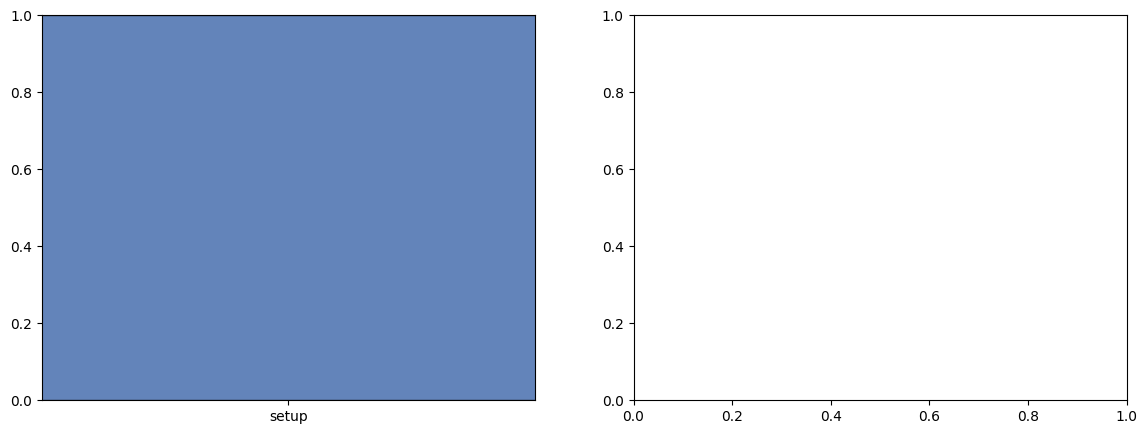

In [22]:
import numpy as np

rates  = [counts[s]["flips"] / max(counts[s]["total"], 1) for s in STAGES]
totals = [counts[s]["total"] for s in STAGES]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

# Bootstrap CIs for flip rates
ci_data = [bootstrap_ci(counts[s].get("flip_list", [])) for s in STAGES]
ci_los  = [d[0] if not np.isnan(d[0]) else 0 for d in ci_data]
ci_his  = [d[1] if not np.isnan(d[1]) else 0 for d in ci_data]
flip_err = [[max(0.0, r - lo) for r, lo in zip(rates, ci_los)],
            [max(0.0, hi - r) for r, hi in zip(rates, ci_his)]]

# Logit diff shifts
shift_means = [np.mean(counts[s]["logit_diff_shifts"])
               if counts[s].get("logit_diff_shifts") else 0.0 for s in STAGES]
shift_stds  = [np.std(counts[s]["logit_diff_shifts"])
               if len(counts[s].get("logit_diff_shifts", [])) >= 2 else 0.0
               for s in STAGES]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: Flip Rate with 95% CI ──
ax = axes[0]
bars = ax.bar(STAGES, rates, color=colors, edgecolor="black", linewidth=0.9,
              alpha=0.87, yerr=flip_err, capsize=6, error_kw={"linewidth": 1.5})
for bar, rate, n in zip(bars, rates, totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{rate:.0%}\n(n={n})", ha="center", va="bottom", fontsize=10,
            fontweight="bold")
ax.set_ylim(0, 1.35)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="0.5 baseline")
ax.set_ylabel("Flip Rate  (Incorrect → Correct)", fontsize=12)
ax.set_xlabel("Semantic Stage Patched", fontsize=12)
ax.set_title("Flip Rate with 95% Bootstrap CI", fontsize=12)
ax.legend(fontsize=9)

# ── Panel 2: Logit Diff Shift ──
ax = axes[1]
max_s = max(shift_stds) if any(s > 0 for s in shift_stds) else 1.0
bars2 = ax.bar(STAGES, shift_means, yerr=shift_stds, color=colors,
               edgecolor="black", linewidth=0.9, alpha=0.87, capsize=6,
               error_kw={"linewidth": 1.5})
for bar, val in zip(bars2, shift_means):
    ypos = val + max_s * 0.15 if val >= 0 else val - max_s * 0.3
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f"{val:+.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean Logit Diff Shift  (patched − baseline)", fontsize=12)
ax.set_xlabel("Semantic Stage Patched", fontsize=12)
ax.set_title("Logit Diff Shift  (±1 std)", fontsize=12)

run_label = "PILOT" if PILOT_MODE else "FULL RUN"
fig.suptitle(
    f"CoT Commitment Point — Qwen2.5-14B-Instruct | GSM8K | organic pairs\n"
    f"Proportional position mapping | All {N_LAYERS} layers | {run_label}",
    fontsize=11, y=1.04,
)
plt.tight_layout()
out_path = SAVE_DIR / "commitment_curve_final.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")


In [ ]:
import gc
import numpy as np

def run_per_layer(pairs, stage, subset_n=None, source_filter="organic"):
    """Per-layer patching for one semantic stage with proportional mapping.

    Patches one layer at a time to find WHICH layers carry the commitment signal.
    """
    subset = [p for p in pairs if source_filter is None or p.get("source") == source_filter]
    if subset_n:
        subset = subset[:subset_n]
    if not subset:
        print(f"No pairs with source_filter={source_filter!r}"); return {}

    layer_counts = {i: {"flips": 0, "total": 0, "logit_diffs": [],
                        "logit_diff_shifts": [], "flip_list": []}
                    for i in range(N_LAYERS)}

    est = len(subset) * N_LAYERS * 0.7 / 60
    print(f"Per-layer: stage='{stage}'  n={len(subset)}  est={est:.1f} min")

    for pair in tqdm(subset, desc=f"per-layer/{stage}"):
        prompt    = make_prompt(pair["question"])
        gt        = pair["gt"]
        wrong_val = pair.get("wrong_val") or extract_gt(pair["wrong"])
        p_len     = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])

        c_ids = tokenizer(prompt + pair["correct"], add_special_tokens=False,
                          return_tensors="pt")["input_ids"][0]
        w_ids = tokenizer(prompt + pair["wrong"],   add_special_tokens=False,
                          return_tensors="pt")["input_ids"][0]

        c_trace_len = len(c_ids) - p_len
        w_trace_len = len(w_ids) - p_len

        masks = get_stage_masks(pair["wrong"], prompt)
        idx   = masks[stage]
        if not idx:
            continue

        # Baseline
        with torch.no_grad():
            bl_logits = model(
                input_ids=w_ids.unsqueeze(0).to("cuda:0"),
                attention_mask=torch.ones(1, len(w_ids), device="cuda:0"),
            ).logits
        baseline_ld = compute_logit_diff(w_ids, bl_logits, gt, wrong_val)
        del bl_logits

        store_pass(c_ids)
        full_acts = dict(_acts)

        for layer_i in range(N_LAYERS):
            _acts.clear()
            if layer_i in full_acts:
                _acts[layer_i] = full_acts[layer_i]

            logits = patch_pass(w_ids, set(idx), p_len, c_trace_len, w_trace_len)
            flip   = did_flip(w_ids, logits, gt)
            ld     = compute_logit_diff(w_ids, logits, gt, wrong_val) if wrong_val else None

            if flip is not None:
                layer_counts[layer_i]["total"] += 1
                layer_counts[layer_i]["flip_list"].append(1 if flip else 0)
                if flip:
                    layer_counts[layer_i]["flips"] += 1
                if ld is not None:
                    layer_counts[layer_i]["logit_diffs"].append(ld)
                if ld is not None and baseline_ld is not None:
                    layer_counts[layer_i]["logit_diff_shifts"].append(ld - baseline_ld)

        _acts.clear()
        del full_acts
        gc.collect()
        torch.cuda.empty_cache()

    return layer_counts


def plot_per_layer(layer_counts, stage):
    layers     = list(range(N_LAYERS))
    flip_rates = [layer_counts[i]["flips"] / max(layer_counts[i]["total"], 1)
                  for i in layers]
    shift_means = [np.mean(layer_counts[i]["logit_diff_shifts"])
                   if layer_counts[i].get("logit_diff_shifts") else 0.0
                   for i in layers]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(layers, flip_rates, "o-", color="#4C72B0", linewidth=1.5, markersize=4)
    axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.4)
    axes[0].set_ylabel("Flip Rate", fontsize=11)
    axes[0].set_title(f"Per-layer commitment — stage: '{stage}'  (organic pairs)", fontsize=12)

    axes[1].plot(layers, shift_means, "s-", color="#C44E52", linewidth=1.5, markersize=4)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_ylabel("Mean Logit Diff Shift", fontsize=11)
    axes[1].set_xlabel("Transformer Layer", fontsize=11)

    plt.tight_layout()
    out = SAVE_DIR / f"per_layer_{stage}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out}")

    return layer_counts

# ── Recommendation ──────────────────────────────────────────────────
try:
    best_stage = max(STAGES, key=lambda s: counts[s]["flips"] / max(counts[s]["total"], 1))
except NameError:
    best_stage = "conclusion"
print(f"Recommended stage for per-layer analysis: '{best_stage}'")
print(f"\nRun:")
print(f"  lc = run_per_layer(pairs, stage='{best_stage}')")
print(f"  plot_per_layer(lc, '{best_stage}')")

## 10 · Next steps

If the pilot looks good (clear flip-rate differences across stages):

1. **Scale up** — set `PILOT_MODE = False`, rerun from Cell 7 (collection already done for pilot)
2. **Bootstrap CIs** — resample `pairs` with replacement 1000× to get 95% CI per stage
3. **Layer-level analysis** — instead of patching all 48 layers, patch one layer at a time to localise commitment
4. **Write up** — the commitment curve is your main figure; segmentation stats + flip rates are Table 1

If pilot fails (all stages ~same flip rate, or all ~0):
- Check `find_answer_logit_pos` output in Cell 9 — if None, #### detection is broken
- Check stage breakdown — if one stage has 0 tokens, segmentation is too coarse
- Check `did_flip` — print `pred` and `gt` for a few examples to verify the comparison logic